Cell 1 – Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)

import warnings
warnings.filterwarnings("ignore")

Cell 2 – Load Dataset

In [2]:
df = pd.read_csv("marketing_campaign.csv", sep="\t")

df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


Cell 3 – Dataset Information

In [3]:
print(df.shape)

df.info()

df.describe()

(2240, 29)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 n

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


Cell 4 – Missing Values

In [4]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

Cell 5 – Handle Missing Values

In [5]:
df["Income"] = df["Income"].fillna(df["Income"].median())

df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Z_CostContact          0
Z_Revenue              0
Response               0
dtype: int64

Cell 6 – Convert Date

In [6]:
df["Dt_Customer"] = pd.to_datetime(
    df["Dt_Customer"],
    dayfirst=True
)

df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0


Cell 7 – Feature Engineering

In [7]:
current_year = 2026

df["Age"] = current_year - df["Year_Birth"]

df["TotalSpending"] = (
    df["MntWines"]
    + df["MntFruits"]
    + df["MntMeatProducts"]
    + df["MntFishProducts"]
    + df["MntSweetProducts"]
    + df["MntGoldProds"]
)

df["PurchaseFrequency"] = (
    df["NumWebPurchases"]
    + df["NumCatalogPurchases"]
    + df["NumStorePurchases"]
)

df["AverageOrderValue"] = (
    df["TotalSpending"] /
    (df["PurchaseFrequency"] + 1)
)

df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,TotalSpending,PurchaseFrequency,AverageOrderValue
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,0,0,0,3,11,1,69,1617,22,70.304348
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,0,0,0,3,11,0,72,27,4,5.400000
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,0,0,0,3,11,0,61,776,20,36.952381
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,0,0,3,11,0,42,53,6,7.571429
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,0,0,0,3,11,0,45,422,14,28.133333


Cell 8 – Distribution of Spending

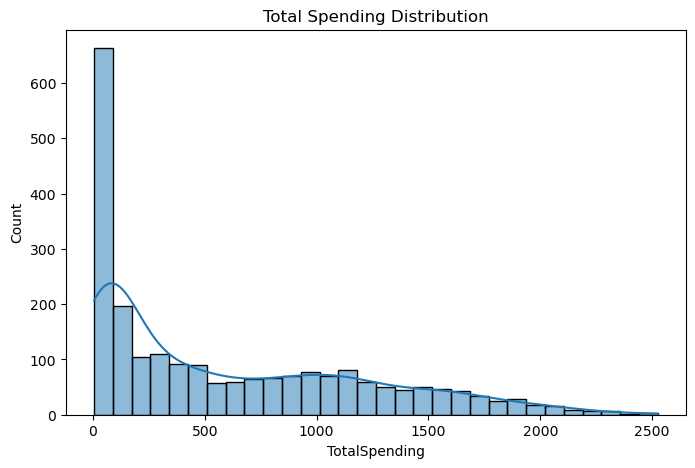

In [8]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["TotalSpending"],
    bins=30,
    kde=True
)

plt.title("Total Spending Distribution")

plt.show()

Cell 9 – Correlation Heatmap

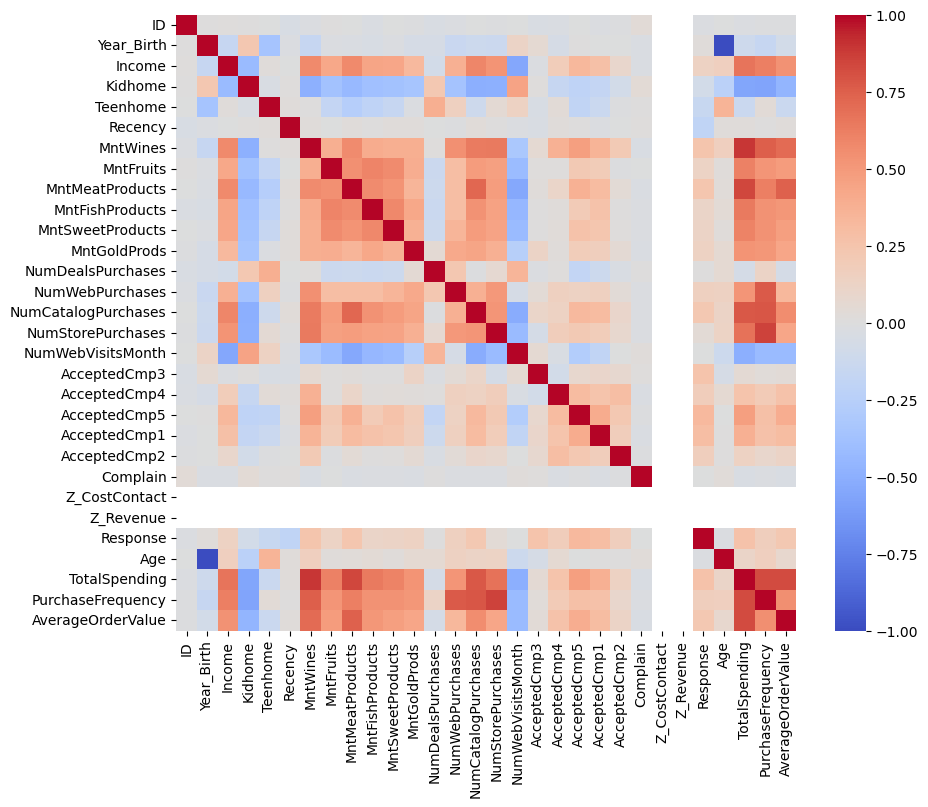

In [9]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    cmap="coolwarm"
)

plt.show()

Cell 10 – Prepare Data for Clustering

In [10]:
cluster_features = df[
    [
        "Income",
        "Recency",
        "PurchaseFrequency",
        "AverageOrderValue",
        "NumWebVisitsMonth"
    ]
]

scaler = StandardScaler()

scaled_data = scaler.fit_transform(cluster_features)

Cell 11 – Elbow Method

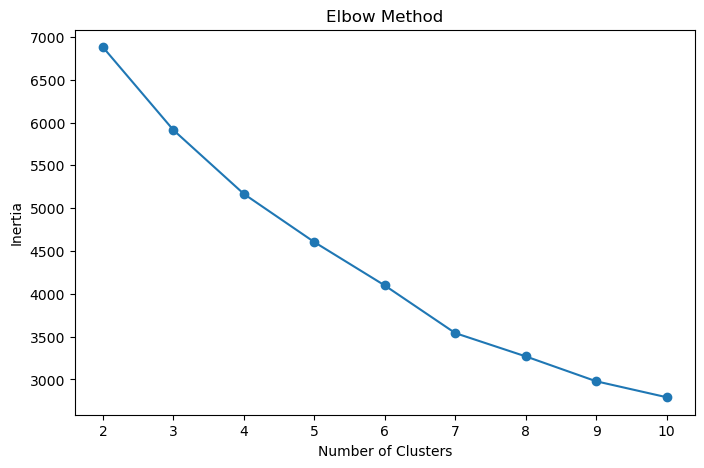

In [11]:
inertia = []

for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(scaled_data)

    inertia.append(model.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(2,11), inertia, marker="o")

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.show()

Cell 12 – Silhouette Scores

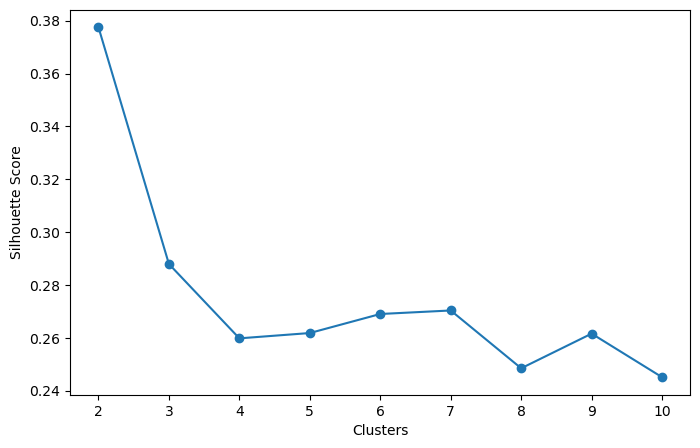

In [12]:
scores = []

for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(scaled_data)

    scores.append(
        silhouette_score(
            scaled_data,
            labels
        )
    )

plt.figure(figsize=(8,5))

plt.plot(range(2,11), scores, marker="o")

plt.xlabel("Clusters")

plt.ylabel("Silhouette Score")

plt.show()

Cell 13 – Final K-Means

In [13]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(
    scaled_data
)

df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,TotalSpending,PurchaseFrequency,AverageOrderValue,Cluster
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,0,0,3,11,1,69,1617,22,70.304348,2
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,0,0,3,11,0,72,27,4,5.400000,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,0,0,3,11,0,61,776,20,36.952381,2
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,0,3,11,0,42,53,6,7.571429,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,0,0,3,11,0,45,422,14,28.133333,3


Cell 14 – Cluster Visualization

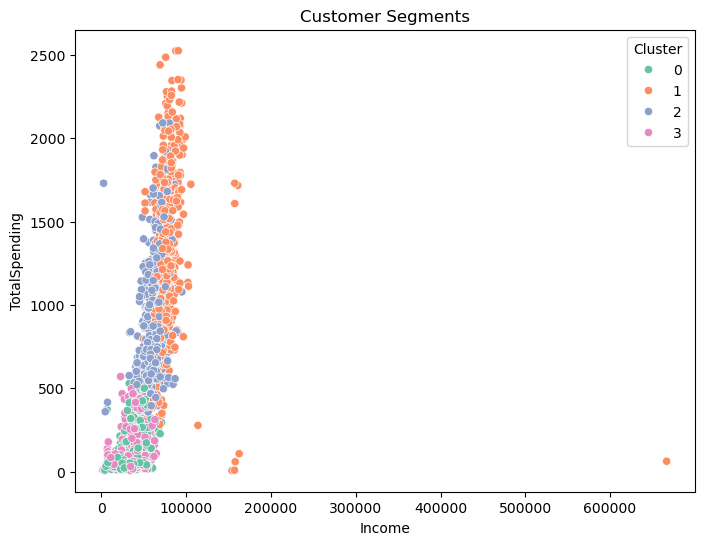

In [14]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Income",
    y="TotalSpending",
    hue="Cluster",
    palette="Set2"
)

plt.title("Customer Segments")

plt.show()

Cell 15 – Segment Summary

In [15]:
segment_summary = df.groupby("Cluster").agg({

    "Income":"mean",

    "TotalSpending":"mean",

    "PurchaseFrequency":"mean",

    "Recency":"mean",

    "AverageOrderValue":"mean"

}).round(2)

segment_summary

,Income,TotalSpending,PurchaseFrequency,Recency,AverageOrderValue
Cluster,,,,,
0,35325.59,121.74,6.45,24.15,13.50
1,78730.79,1339.92,18.44,51.52,71.45
2,60989.22,897.32,19.36,46.61,43.85
3,36357.05,134.80,6.77,75.81,14.48


Cell 16 – Prepare Data for Machine Learning

In [18]:
features = [
    "Income",
    "Recency",
    "PurchaseFrequency",
    "AverageOrderValue",
    "NumWebVisitsMonth",
    "Age"
]

X = df[features]

# Regression Target
y_reg = df["TotalSpending"]

# Classification Target
y_cls = df["Response"]

Cell 17 – Train-Test Split (Regression)

In [19]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X,
    y_reg,
    test_size=0.2,
    random_state=42
)

Cell 18 – Ridge Regression

In [20]:
ridge = Ridge(alpha=1.0)

ridge.fit(X_train_reg, y_train_reg)

pred_reg = ridge.predict(X_test_reg)

print("MAE :", mean_absolute_error(y_test_reg, pred_reg))

print("RMSE :", np.sqrt(mean_squared_error(y_test_reg, pred_reg)))

print("R2 Score :", r2_score(y_test_reg, pred_reg))

MAE : 132.72025282146083
RMSE : 175.84422788306674
R2 Score : 0.9130362820334208


Cell 19 – Save Regression Predictions

In [21]:
regression_predictions = pd.DataFrame({

    "Actual": y_test_reg,

    "Predicted": pred_reg

})

regression_predictions.head()

,Actual,Predicted
324,630,751.515367
96,606,759.752948
2104,75,50.915017
1259,2279,1640.164625
1061,1155,1189.133141


Cell 20 – Train-Test Split (Classification)

In [22]:
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(

    X,

    y_cls,

    test_size=0.2,

    random_state=42,

    stratify=y_cls

)

Cell 21 – Logistic Regression

In [23]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(

    X_train_cls,

    y_train_cls

)

pred_cls = log_model.predict(X_test_cls)

Cell 22 – Classification Metrics

In [24]:
print("Accuracy :", accuracy_score(y_test_cls, pred_cls))

print("Precision :", precision_score(y_test_cls, pred_cls))

print("Recall :", recall_score(y_test_cls, pred_cls))

print("F1 Score :", f1_score(y_test_cls, pred_cls))

print(

    "ROC-AUC :",

    roc_auc_score(

        y_test_cls,

        log_model.predict_proba(X_test_cls)[:,1]

    )

)

Accuracy : 0.8504464285714286
Precision : 0.5
Recall : 0.07462686567164178
F1 Score : 0.12987012987012986
ROC-AUC : 0.7850315352371998


Cell 23 – Confusion Matrix

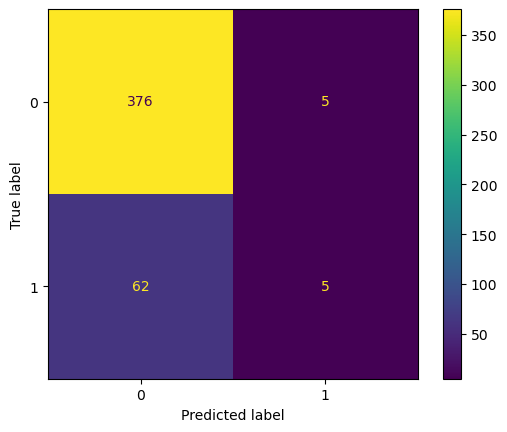

In [25]:
cm = confusion_matrix(

    y_test_cls,

    pred_cls

)

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm

)

disp.plot()

plt.show()

Cell 24 – GridSearchCV

In [26]:
param_grid = {

    "C":[0.01,0.1,1,10],

    "solver":["liblinear","lbfgs"]

}

grid = GridSearchCV(

    LogisticRegression(max_iter=1000),

    param_grid,

    cv=5,

    scoring="accuracy"

)

grid.fit(

    X_train_cls,

    y_train_cls

)

print(grid.best_params_)

print(grid.best_score_)

{'C': 0.01, 'solver': 'liblinear'}
0.8565848648480415


Cell 25 – Best Model

In [27]:
best_model = grid.best_estimator_

best_pred = best_model.predict(

    X_test_cls

)

print(

    "Best Accuracy :",

    accuracy_score(

        y_test_cls,

        best_pred

    )

)

Best Accuracy : 0.859375


Cell 26 – Customer Segment Profile

In [28]:
cluster_profile = df.groupby("Cluster")[

    [

        "Income",

        "TotalSpending",

        "PurchaseFrequency",

        "AverageOrderValue",

        "Recency"

    ]

].mean().round(2)

cluster_profile

,Income,TotalSpending,PurchaseFrequency,AverageOrderValue,Recency
Cluster,,,,,
0,35325.59,121.74,6.45,13.50,24.15
1,78730.79,1339.92,18.44,71.45,51.52
2,60989.22,897.32,19.36,43.85,46.61
3,36357.05,134.80,6.77,14.48,75.81


Cell 27 – Business Insights

In [29]:
for cluster in sorted(df["Cluster"].unique()):

    print("="*60)

    print("Cluster :", cluster)

    print(cluster_profile.loc[cluster])

    print()

Cluster : 0
Income               35325.59
TotalSpending          121.74
PurchaseFrequency        6.45
AverageOrderValue       13.50
Recency                 24.15
Name: 0, dtype: float64

Cluster : 1
Income               78730.79
TotalSpending         1339.92
PurchaseFrequency       18.44
AverageOrderValue       71.45
Recency                 51.52
Name: 1, dtype: float64

Cluster : 2
Income               60989.22
TotalSpending          897.32
PurchaseFrequency       19.36
AverageOrderValue       43.85
Recency                 46.61
Name: 2, dtype: float64

Cluster : 3
Income               36357.05
TotalSpending          134.80
PurchaseFrequency        6.77
AverageOrderValue       14.48
Recency                 75.81
Name: 3, dtype: float64



Cell 28 – Save Output Files

In [30]:
segment_summary.to_csv(

    "customer_segments.csv",

    index=True

)

cluster_profile.to_csv(

    "cluster_profile.csv"

)

regression_predictions.to_csv(

    "regression_predictions.csv",

    index=False

)

classification_predictions = pd.DataFrame({

    "Actual": y_test_cls,

    "Predicted": best_pred

})

classification_predictions.to_csv(

    "classification_predictions.csv",

    index=False

)

best_parameters = pd.DataFrame(

    [grid.best_params_]

)

best_parameters.to_csv(

    "best_hyperparameters.csv",

    index=False

)

print("All output files saved successfully.")

All output files saved successfully.


Cell 29 – Model Comparison

In [31]:
comparison = pd.DataFrame({

    "Model":[

        "Ridge Regression",

        "Logistic Regression"

    ],

    "Metric":[

        r2_score(

            y_test_reg,

            pred_reg

        ),

        accuracy_score(

            y_test_cls,

            best_pred

        )

    ]

})

comparison

,Model,Metric
0,Ridge Regression,0.913036
1,Logistic Regression,0.859375


Cell 30 – Save Model Comparison

In [32]:
comparison.to_csv(

    "model_comparison.csv",

    index=False

)

comparison

,Model,Metric
0,Ridge Regression,0.913036
1,Logistic Regression,0.859375


Cell 31 – Final Dataset Preview

In [33]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,TotalSpending,PurchaseFrequency,AverageOrderValue,Cluster
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,0,0,3,11,1,69,1617,22,70.304348,2
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,0,0,3,11,0,72,27,4,5.400000,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,0,0,3,11,0,61,776,20,36.952381,2
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,0,3,11,0,42,53,6,7.571429,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,0,0,3,11,0,45,422,14,28.133333,3


Cell 32 – Completion Message

In [35]:
print("="*70)
print("Task 8 Completed Successfully")
print("="*70)

print("Generated Files:")
print("---------------------------")

print("customer_segments.csv")
print("cluster_profile.csv")
print("classification_predictions.csv")
print("regression_predictions.csv")
print("best_hyperparameters.csv")
print("model_comparison.csv")

print("\nMachine Learning Models Used:")
print("-----------------------------")
print("✓ K-Means Clustering")
print("✓ Ridge Regression")
print("✓ Logistic Regression")
print("✓ GridSearchCV")


Task 8 Completed Successfully
Generated Files:
---------------------------
customer_segments.csv
cluster_profile.csv
classification_predictions.csv
regression_predictions.csv
best_hyperparameters.csv
model_comparison.csv

Machine Learning Models Used:
-----------------------------
✓ K-Means Clustering
✓ Ridge Regression
✓ Logistic Regression
✓ GridSearchCV
